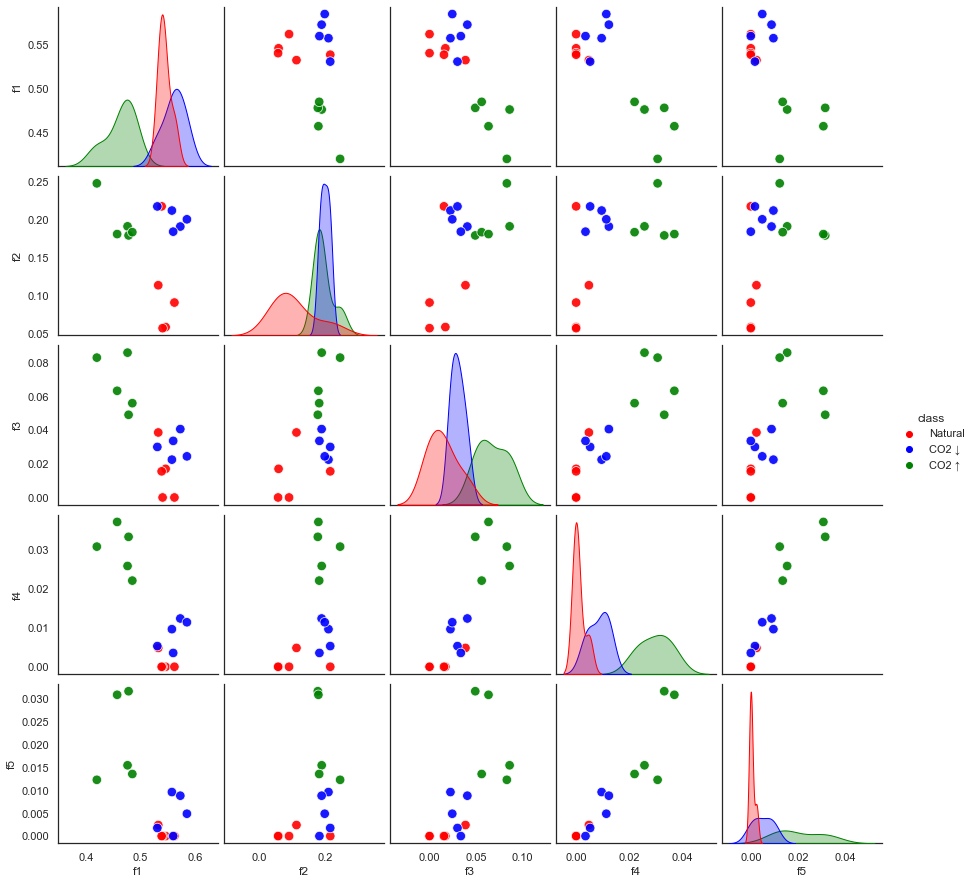

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import arff


# -------------------------------------------------
# 1. Ler ARFF
# -------------------------------------------------
data, meta = arff.loadarff("B014-S04567_distribEntropy.arff")
df = pd.DataFrame(data)

# converter classe (bytes → string)
df.iloc[:, -1] = df.iloc[:, -1].apply(
    lambda x: x.decode() if isinstance(x, bytes) else x
)

# -------------------------------------------------
# 2. Selecionar descritores
# -------------------------------------------------
features = df.columns[:5]
class_col = df.columns[-1]

# -------------------------------------------------
# 3. Renomear classes (só visualização)
# -------------------------------------------------
class_map = {
    "AMB":  "Natural",
    "CO2":  "CO2 ↑",
    "UM90": "CO2 ↓"
}

palette = {
    "Natural": "red",
    "CO2 ↑":   "green",
    "CO2 ↓":   "blue"
}

df[class_col] = df[class_col].map(class_map) 
# -------------------------------------------------
# 4. Pairplot
# -------------------------------------------------
sns.set(style="white", font_scale=1.0)

g = sns.pairplot(
    df,
    vars=features,
    hue=class_col, 
    palette=palette,
    diag_kind="kde",      # ou "hist"
    plot_kws=dict(
        s=90,
        alpha=0.9
    ),
    diag_kws=dict(
        fill=True,
        alpha=0.3
    )
)
 
g.savefig("pairplot.svg")
plt.show()
